In [26]:
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [27]:
# Caminhos padrões para os arquivos e pastas
caminho_processed = "../dados/processed"
caminho_gold = "../dados/gold"

In [28]:
# Visualização das colunas de dados 'float' para somente 2 casas decimais
pd.set_option('display.float_format', '{:,.2f}'.format)

In [96]:
df_analitico = pd.read_parquet(os.path.join(caminho_gold, "df_gold.parquet"))

# --- RENTABILIDADE ---
# ROE (Return on Equity)
df_analitico['kpi_roe'] = df_analitico['lucro_liquido'] / df_analitico['patrimonio_liquido']

# --- QUALIDADE ---
# Dependência de "Outras Receitas".
# Se o banco depende muito de receitas não-operacionais, isso é não recorrente.
# Fórmula: Outras Receitas / (Total de Receitas Operacionais)
df_analitico['receita_total_estimada'] = df_analitico['resultado_intermediacao'] + df_analitico['outras_receitas_despesas'] + df_analitico['resultado_pagamentos'].fillna(0)

df_analitico['kpi_qualidade_lucro'] = (df_analitico['outras_receitas_despesas'] + df_analitico['Resultado de Participações (t)']) / df_analitico['receita_total_estimada']

# --- VOLUMETRIA ---
# Tamanho do Banco (Log) para separar Pequenos de Gigantes
df_analitico['tamanho_log'] = np.log10(df_analitico['ativo_total'])

# Taxa média (Yield)
df_analitico['yield_carteira'] = df_analitico['Rendas de Operações de Crédito (c)'] / df_analitico['carteira_credito']
df_analitico['yield_carteira'] = df_analitico['yield_carteira'].replace([np.inf, -np.inf], np.nan)

df_analitico['custo_funding'] = df_analitico['Despesa de Juros com Captações (g1)'].abs()
# Custo Implícito = Quanto pagou de juros / Quanto tinha de dívida
df_analitico['taxa_funding_implicita'] = df_analitico['custo_funding'] / df_analitico['captacoes']

df_analitico['data_base'].unique()

c:\Users\Thiag\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


<DatetimeArray>
['2022-12-01 00:00:00', '2023-03-01 00:00:00', '2023-06-01 00:00:00',
 '2023-09-01 00:00:00', '2023-12-01 00:00:00', '2024-03-01 00:00:00',
 '2024-06-01 00:00:00', '2024-09-01 00:00:00', '2024-12-01 00:00:00',
 '2025-03-01 00:00:00', '2025-06-01 00:00:00']
Length: 11, dtype: datetime64[ns]

In [30]:
#Código para auxiliar a encontrar as intituições. Pelo fato de ter várias no conglomerado financeiro
filtro_nome = df_analitico['instituicao'].str.contains('INTER', case=False, na=False)
filtro_data = df_analitico['data_base'] == '2022-12-01'

bancosss = df_analitico[filtro_nome & filtro_data]

resultado = bancosss[['data_base','instituicao','ativo_total']]

In [31]:
bancos_comparacao = [
    # Varejo e Consignado
    'BANCO PAN S.A.',
    'BANCO BMG S.A.',
    'BANCO MERCANTIL DO BRASIL S.A.',
    'BANCO AGIBANK S.A.',
    'BRB - BANCO DE BRASILIA S.A.',
    'BANCO DAYCOVAL S.A.',
    
    # Middle Market e Atacado (Concorrentes PJ do Master)
    'BANCO PINE S.A.',
    'BANCO SOFISA S.A.',
    'BANCO FIBRA S.A.',
    'BANCO ABC BRASIL S.A.',
    
    # Benchmarks de Nicho e Risco
    'OMNI BANCO S.A.',
    'PARANÁ BANCO S.A.',
    
    # Digital e Investment Banking
    'BANCO INTER S.A.'
]

bancos = [
    'BANCO MASTER S/A',
    'BANCO PAN S.A.',
    'BANCO BMG S.A.',
    'BANCO MERCANTIL DO BRASIL S.A.',
    'BANCO AGIBANK S.A.',
    'BRB - BANCO DE BRASILIA S.A.',
    'BANCO DAYCOVAL S.A.',
    'BANCO PINE S.A.',
    'BANCO SOFISA S.A.',
    'BANCO FIBRA S.A.',
    'BANCO ABC BRASIL S.A.',
    'OMNI BANCO S.A.',
    'PARANÁ BANCO S.A.',
    'BANCO INTER S.A.'
]

# **Análise de Correlação e Benchmark**

## **O Padrão de Mercado (Benchmark)**
Ao analisar a matriz de correlação dos pares, foi possível observar:
* **Ativo Total vs. Lucro Líquido (0.66):** A correlação é **Positiva Moderada**, e não Muito Forte.
* **Insight:** O mercado premia a **Eficiência e o Nicho**. Um banco pode ter metade do Ativo de outro, mas gerar o mesmo Lucro se tiver spreads melhores e custos menores.
* Isso confirma que, no ecossistema bancário médio brasileiro, **Modelo de Negócio > Tamanho**.
* Bancos de nicho (como o Agibank ou Omni) conseguem gerar lucros desproporcionais ao seu tamanho devido às taxas de juros elevadas (Yield), enquanto bancos corporativos (ABC) dependem de volume e eficiência operacional.

## **O Posicionamento do Banco Master**
Ao analisar o Banco Master separadamente identifiquei uma divergência estratégica entre "Marca" e "Balanço":

### Identidade vs. Realidade
* **Expectativa:** Pelo posicionamento de marca ("Banco de Investimento"), esperava uma correlação de indicadores como Yields controlados e alavancagem conservadora.
* **Realidade (Dados):** Os indicadores financeiros do Master (Yield da Carteira > 1.0 e ROE alavancado).

### O Risco do "Yield de Varejo" com "Funding de Atacado"
* O banco opera com **Custo de Capital de Banco Médio** mas precisa buscar **Retornos de Financeira de Crédito** para fechar a conta. Isso cria uma pressão estrutural por produtos de risco, explicando o alto volume de reclamações sobre "Cobrança Indevida" detectado na etapa de NLP.

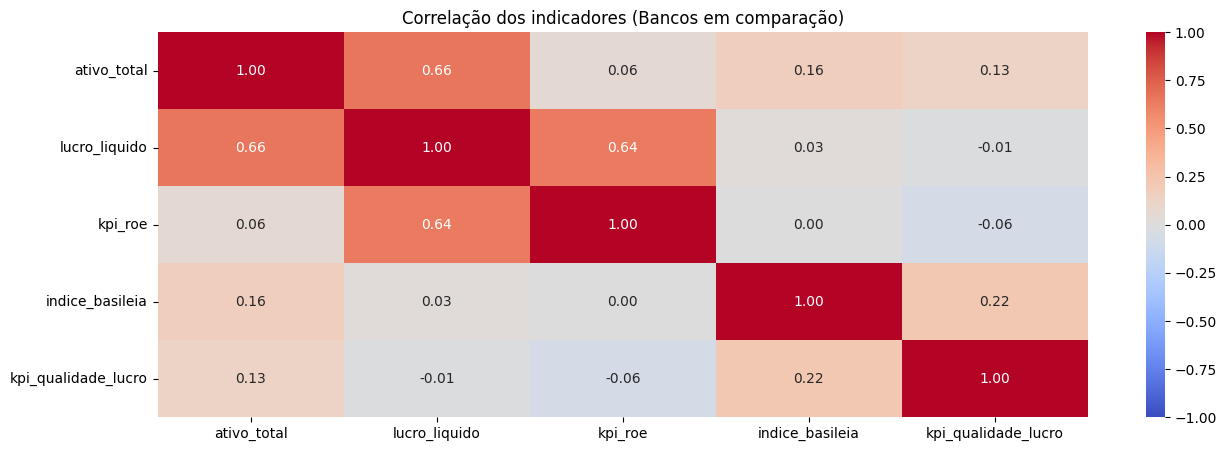

In [32]:
colunas_visualizar = [
    'instituicao',
    'ativo_total',
    'lucro_liquido',
    'kpi_roe',
    'indice_basileia',
    'kpi_qualidade_lucro'
]

df_bancos = df_analitico.loc[df_analitico['instituicao'].isin(bancos_comparacao),colunas_visualizar].copy()


correlação_bancos = df_bancos.corr(
    method='pearson',
    numeric_only=True
)

plt.figure(figsize=(15,5))
sns.heatmap(
    correlação_bancos,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1, vmax=1,
    center=0
)
plt.title('Correlação dos indicadores (Bancos em comparação)')
plt.show()

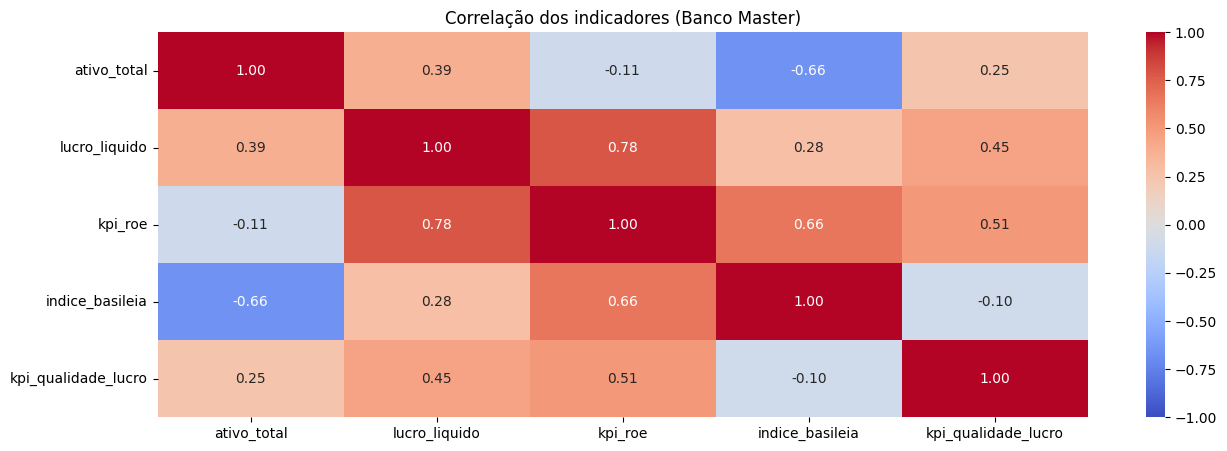

In [33]:
df_master = df_analitico.loc[df_analitico['instituicao'] == 'BANCO MASTER S/A',colunas_visualizar].copy()

correlação_master = df_master.corr(
    method='pearson',
    numeric_only=True
)

plt.figure(figsize=(15,5))
sns.heatmap(
    correlação_master,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1, vmax=1,
    center=0
)
plt.title('Correlação dos indicadores (Banco Master)')
plt.show()

# **Análise de Volumetria:**

## **Hipercrescimento do Ativo**
Ao isolar a curva de Ativo Total, notamos uma inclinação muito superior à média do setor.
* **Diagnóstico:** O Banco Master apresentou um crescimento acelerado e descorrelacionado do PIB ou do crescimento natural de crédito do país.
* Esse comportamento é típico de **Crescimento Inorgânico**, realizado através da compra massiva de carteiras de crédito ou aquisição de outras instituições, e não pela captação tradicional no varejo.

## **Hipótese Estratégica**
Cruzando os dados com o contexto de mercado, o hipercrescimento do balanço sustenta a hipótese de preparação para um evento de liquidez (Aquisição):
* Aumentar os Ativos melhora o *Valuation* e a relevância sistêmica da instituição em uma mesa de negociação.

## **Conclusão Final**
O movimento de inflar o balanço seguido pela liquidação e intervenção feita pelo bacen em Novembro/2025, mostra um ciclo de **Tentativa de Saída Estratégica**. Os dados sugerem que o banco buscou ganhar indicadores rapidamente para se tornar atraente para um parceiro (como o BRB).

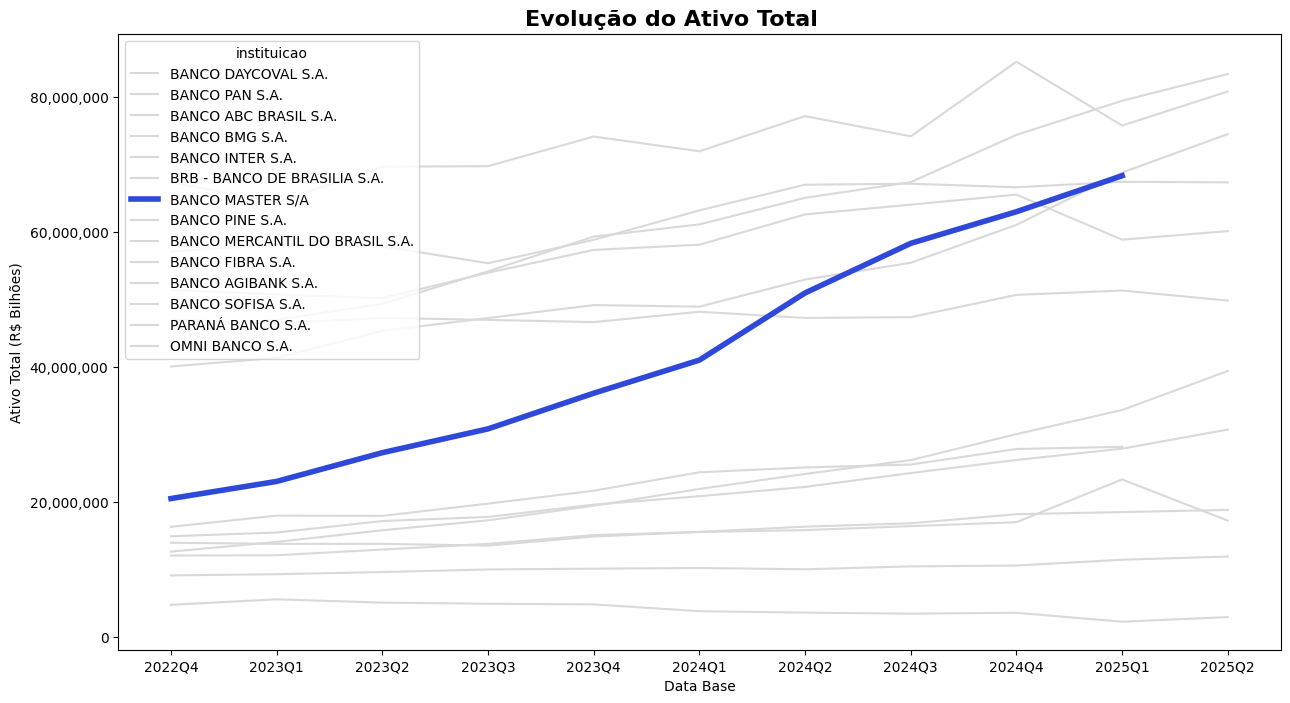

In [34]:
df_analitico['Trimestre'] = df_analitico['data_base'].dt.to_period('Q').astype(str)

df_bancos = df_analitico.loc[df_analitico['instituicao'].isin(bancos)].copy()

banco_foco = 'BANCO MASTER S/A'
todos_bancos = df_bancos['instituicao'].unique()

# Lógica para destacar o Banco Master na análise
paleta_cores = {banco: "#2E48DA" if banco == banco_foco else '#d9d9d9' for banco in todos_bancos}
espessuras = {banco: 4.0 if banco == banco_foco else 1.5 for banco in todos_bancos}

plt.figure(figsize=(15,8))

sns.lineplot(
    data=df_bancos,
    x='Trimestre',
    y='ativo_total',
    hue='instituicao',
    size='instituicao',
    palette=paleta_cores,
    sizes=espessuras
)

ax = plt.gca() # Pega o eixo atual
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.title('Evolução do Ativo Total', fontsize=16, fontweight='bold', loc='left', x=0.35)
plt.ylabel('Ativo Total (R$ Bilhões)')
plt.xlabel('Data Base')
plt.show()

# **Análise de Qualidade do Lucro**

## **O Teste da máscara contábil**
Ao cruzar o **ROE** com a dependência de **Outras Receitas**, busquei identificar se a rentabilidade do banco é sustentável ou vinda de  Eventos não-recorrentes.

## **A conclusão com Dados**
* O Banco Master apresenta uma correlação saudável neste aspecto. O Master mostra uma dependência controlada de "Outras Receitas".
* **Diagnóstico:** O lucro é **Operacional**. A rentabilidade elevada (ROE) vêm de maioria pela atividade de Intermediação Financeira/Crédito.

## **Conclusão Final**
O risco do Banco Master não é contábil (fraude de balanço), é  **Operacional e de Crédito**. A instituição é uma máquina de juros eficiente, transferindo o custo de captação para o cliente final. O perigo está na sustentabilidade da carteira: clientes dispostos a pagar taxas tão altas possuem pior score de crédito, tornando o banco sensível a aumento de inadimplência.

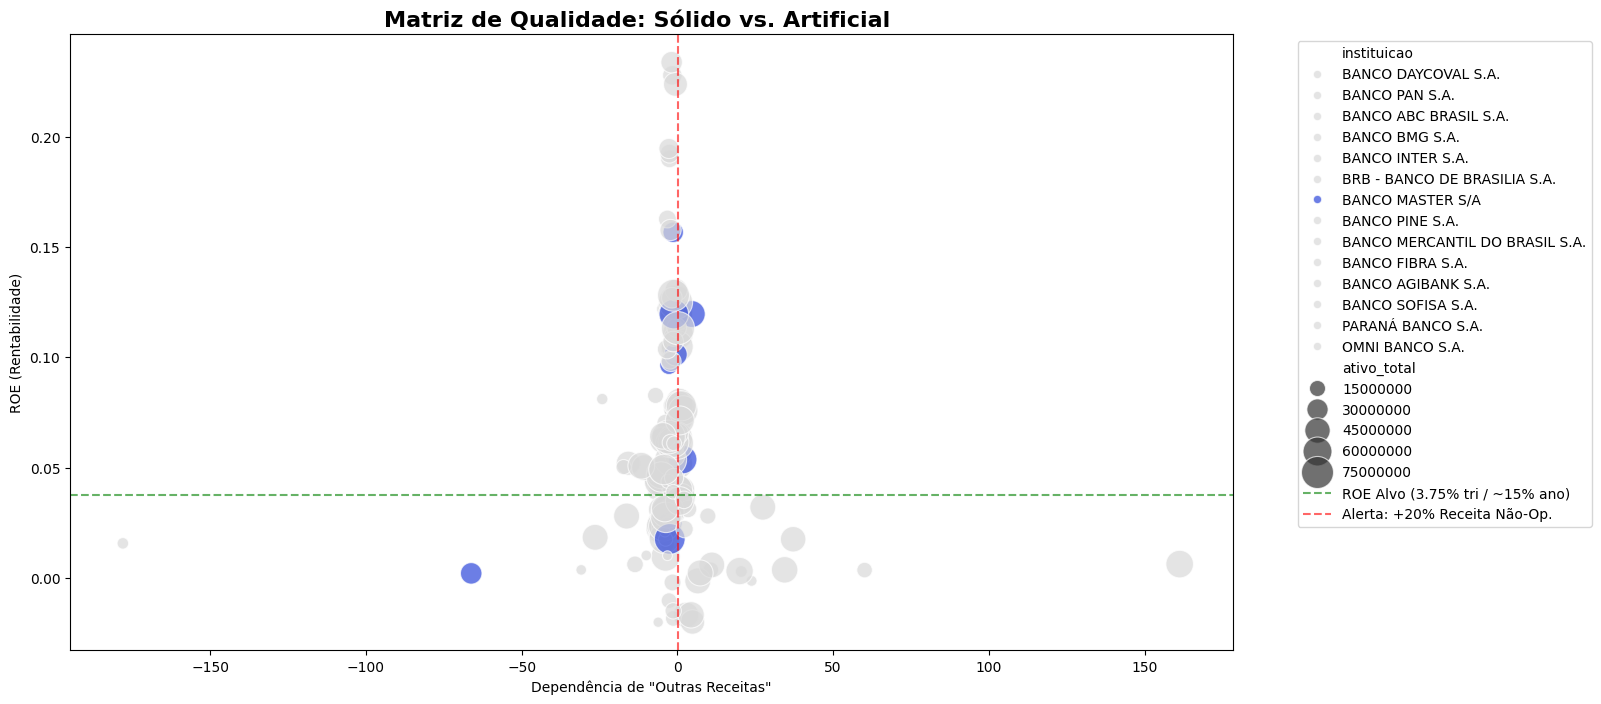

In [35]:
plt.figure(figsize=(15, 8))

# Lógica para destacar o Banco Master na análise
paleta_cores = {banco: "#2E48DA" if banco == banco_foco else '#d9d9d9' for banco in todos_bancos}
espessuras = {banco: 4.0 if banco == banco_foco else 1.5 for banco in todos_bancos}

sns.scatterplot(
    data=df_bancos,
    x='kpi_qualidade_lucro',
    y='kpi_roe',
    hue='instituicao',
    size='ativo_total',
    sizes=(50, 600),
    alpha=0.7,
    palette=paleta_cores
)

# Eixo Y: ROE Trimestral de ~3.75% (equivale a ~15% anual)
plt.axhline(y=0.0375, color='green', linestyle='--', alpha=0.6, label='ROE Alvo (3.75% tri / ~15% ano)')
# Eixo X: Alerta se +20% da receita for não-core
plt.axvline(x=0.20, color='red', linestyle='--', alpha=0.6, label='Alerta: +20% Receita Não-Op.')

plt.title('Matriz de Qualidade: Sólido vs. Artificial', fontsize=16, fontweight='bold', loc='left', x=0.27)
plt.ylabel('ROE (Rentabilidade)')
plt.xlabel('Dependência de "Outras Receitas"')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# **Correlação Crítica: (Funding x Basileia)**

## **O Diagnóstico de Basileia**
É possível observar o **Índice de Basileia** do Banco Master operando próximo aos limites regulatórios mínimos, e descolado do benchmark, consequentemente uma fragilidade estrutural de capital. O banco possui pouco dinheiro em caixa para absorver descontroles.

## **A Precificação do Risco (Funding)**
* A necessidade de oferecer taxas de captação muito acima é uma resposta direta à percepção de risco de basileia (Solvência). O banco paga caro não porque quer, mas porque precisa de liquidez imediata para girar a operação. Ou até mesmo relacionado a situação passada atualmente, buscando aumentar suas contas, para uma possível aquisição.

## **A Consequência Estratégica (High Yield Forçado)**
* O perfil arriscado da carteira de crédito, e as reclamações decorrentes, não é uma"escolha comercial livre, mas sim uma **necessidade financeira de sobrevivência** imposta pela deterioração da solvência.

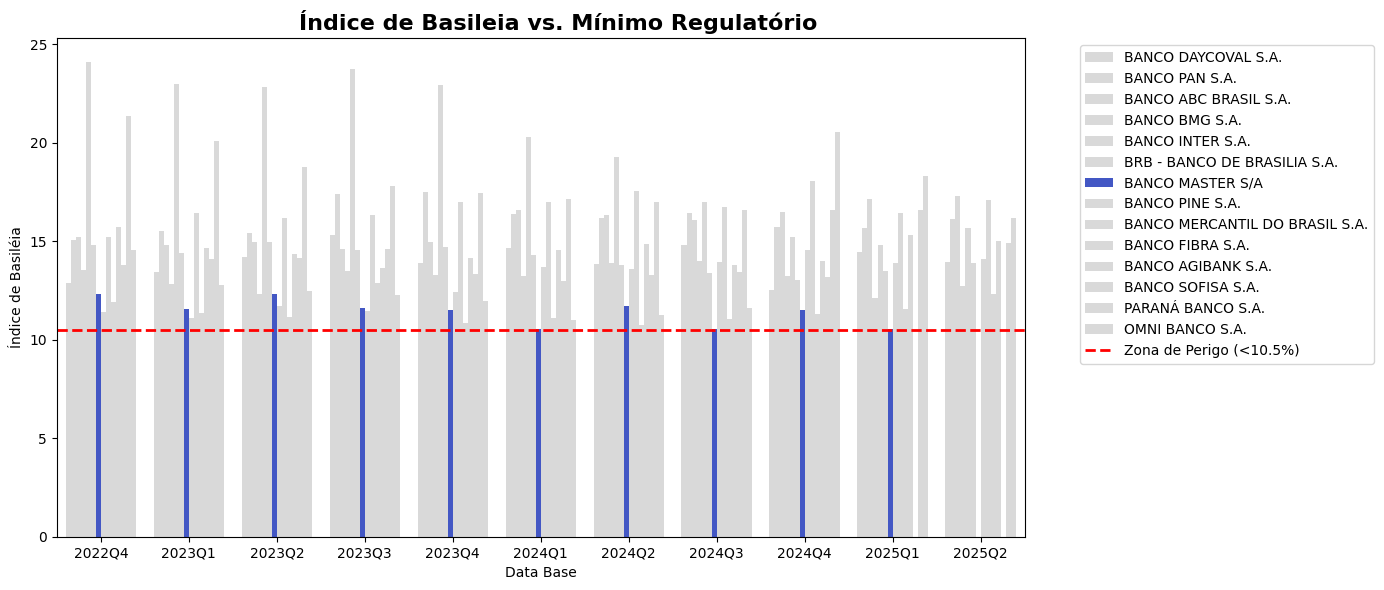

'\n1. A Estrutura da Exigência (O Mínimo Real)\nPara a maioria dos bancos (segmentos S1 a S4), a composição mínima é:\n\n8,0% (Mínimo Regulatório - Patrimônio de Referência)\n\n2,5% (Adicional de Conservação de Capital - Buffer)\n\nTotal Efetivo: 10,5%\n\nO que acontece se cair?\n\nAbaixo de 10,5%: O banco ainda pode operar, mas sofre restrições automáticas (não pode distribuir dividendos acima do mínimo obrigatório, pagar bônus variáveis a executivos ou recomprar ações) até recompor o capital.\n\nAbaixo de 8,0%: O banco entra em desconformidade grave, sujeito a intervenção ou liquidação pelo Banco Central.\n'

In [36]:
# Lógica para destacar o Banco Master na análise
paleta_cores = {banco: "#2E48DA" if banco == banco_foco else '#d9d9d9' for banco in todos_bancos}

plt.figure(figsize=(14, 6))

sns.barplot(
    data=df_bancos,
    x='Trimestre',
    y='indice_basileia',
    hue='instituicao',
    palette=paleta_cores
)

plt.title('Índice de Basileia vs. Mínimo Regulatório', fontsize=16, fontweight='bold', loc='left', x=0.25)
plt.ylabel('Índice de Basiléia')
plt.xlabel('Data Base')

# Linha de Perigo (Bancos costumam quebrar abaixo de 5-8% de capital próprio real)
plt.axhline(y=10.5, color='red', linestyle='--', linewidth=2, label='Zona de Perigo (<10.5%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

'''
1. A Estrutura da Exigência (O Mínimo Real)
Para a maioria dos bancos (segmentos S1 a S4), a composição mínima é:

8,0% (Mínimo Regulatório - Patrimônio de Referência)

2,5% (Adicional de Conservação de Capital - Buffer)

Total Efetivo: 10,5%

O que acontece se cair?

Abaixo de 10,5%: O banco ainda pode operar, mas sofre restrições automáticas (não pode distribuir dividendos acima do mínimo obrigatório, pagar bônus variáveis a executivos ou recomprar ações) até recompor o capital.

Abaixo de 8,0%: O banco entra em desconformidade grave, sujeito a intervenção ou liquidação pelo Banco Central.
'''

# A Estratégia de Precificação

## O Diagnóstico Comparativo
Ao comparar a métrica de **Yield (Receita de Juros / Carteira de Crédito)**, é possível observar uma grande de precificação:
* **Benchmarks Conservadores (ABC, Pine):** trabalham com Yields baixos (~0.50), característicos de crédito corporativo (baixo risco, spreads apertados).
* **Benchmarks de Varejo (Daycoval, Pan):** trabalham na faixa de 0.70 a 0.80, compatível com o mix de produtos financeiros.
* **Banco Master:** Apresenta um Yield superior a **1.0 (100%+)**.

## A Correlação com a captação de crédito
Este Yield agressivo não é necessariamente uma escolha de lucro extra, mas uma **necessidade de solvência (Basileia)**:
* Na análise de Funding foi possível ver que o Master paga muito caro para captar dinheiro.
* Se o custo do dinheiro é alto, o banco é obrigado a cobrar taxas abusivas na ponta final para manter um *Spread* positivo.

## Conclusão
O banco atrai clientes dispostos a pagar taxas fora de mercado. Isso gera receita rápida no curto prazo, mas constrói uma carteira de crédito de baixa qualidade e alto risco de inadimplência e reclamações, confirmado pelo NLP.

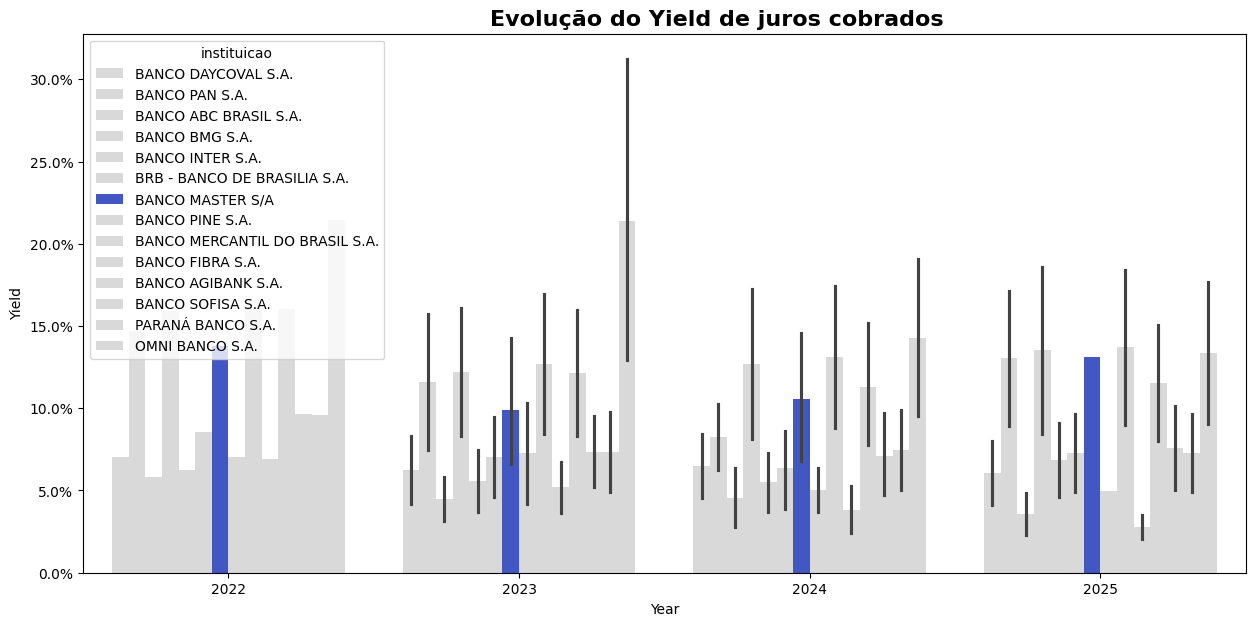

In [37]:
# Lógica para destacar o Banco Master na análise
paleta_cores = {banco: "#2E48DA" if banco == banco_foco else '#d9d9d9' for banco in todos_bancos}

df_analitico['Year'] = df_analitico['data_base'].dt.year

df_bancos = df_analitico.loc[df_analitico['instituicao'].isin(bancos)].copy()

plt.figure(figsize=(15,7))

sns.barplot(
    data=df_bancos,
    x='Year',
    y='yield_carteira',
    hue='instituicao',
    palette=paleta_cores
)


ax = plt.gca()
plt.gca().yaxis.set_major_formatter(ticker.PercentFormatter(1.0))
plt.title('Evolução do Yield de juros cobrados', fontsize=16, fontweight='bold', loc='left', x=0.35)
plt.ylabel('Yield')
plt.xlabel('Year')
plt.show()